In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import os
import sys
sys.path.append('../core')
from config import processed_data_path, results_path
from model_func import save_model, save_report, save_figure
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, f1_score

In [3]:
X_path = os.path.join(processed_data_path, 'X_data.npy')
y_path = os.path.join(processed_data_path, 'y_data.npy')
feature_names_path = os.path.join(processed_data_path, 'feature_names.npy')

X = np.load(X_path)
y = np.load(y_path)
feature_names = np.load(feature_names_path, allow_pickle=True)

In [4]:
risk_scores_path = os.path.join(processed_data_path, 'nlp_finetuned_features.csv')
df_risk_scores = pd.read_csv(risk_scores_path)
df_risk_scores.head()

,hadm_id,nlp_finetuned_risk_score
0,27897940,0.571344
1,26913865,0.165627
2,24947999,0.157963
3,25242409,0.116425
4,25911675,0.236676


In [5]:
risk_scores = df_risk_scores['nlp_finetuned_risk_score'].values.reshape(-1, 1)

In [6]:
X_final = np.hstack((X, risk_scores))
feature_names_final = np.append(feature_names, 'nlp_finetuned_risk_score')

In [7]:
print(f"Final Feature Set: {X_final.shape[1]} features")

Final Feature Set: 22 features


In [8]:
nlp_indices = [i for i, name in enumerate(feature_names_final) if 'nlp_' in name]
print(nlp_indices)

[3, 4, 21]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
model = XGBClassifier(scale_pos_weight=10, eval_metric='logloss', use_label_encoder=False, random_state=42)

In [11]:
model.fit(X_train, y_train)
save_model('XGBClassifier', model, "enhanced")

Model saved successfully at: E:\IIT\IRP\results\models\enhanced\XGBClassifier.joblib


c:\Users\damitha\.conda\envs\irp_gpu\lib\site-packages\xgboost\training.py:200: UserWarning: [17:06:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [13]:
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Survivor', 'Mortality'])

In [14]:
print(f"\nModel Performance: XGBClassifier")
print(f"AUC-ROC: {auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(report) # <--- View in Notebook
save_report('XGBClassifier', report, "enhanced", auc=auc, f1=f1)


Model Performance: XGBClassifier
AUC-ROC: 0.7706
F1-Score: 0.2817

Classification Report:
              precision    recall  f1-score   support

    Survivor       0.97      0.95      0.96      5269
   Mortality       0.24      0.34      0.28       267

    accuracy                           0.92      5536
   macro avg       0.60      0.64      0.62      5536
weighted avg       0.93      0.92      0.92      5536

Report saved successfully at: E:\IIT\IRP\results\metrics\enhanced\XGBClassifier.txt


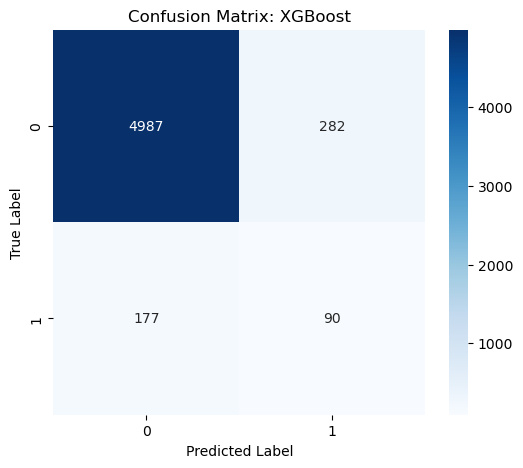

In [15]:
cm = confusion_matrix(y_test, y_pred)
fig_cm, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix: XGBoost')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.show()

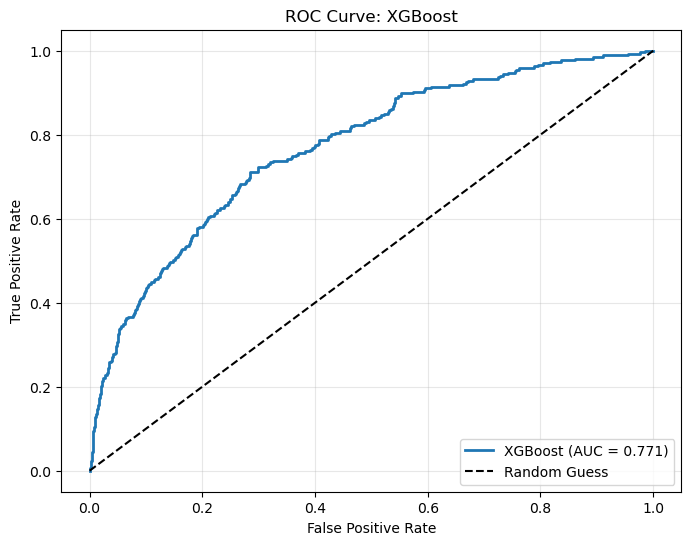

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig_roc, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})", lw=2)
ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax.set_title(f'ROC Curve: XGBoost')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# save_figure(name, fig_roc, "baseline", filename_suffix="roc_curve") # Save
plt.show()

In [17]:
from sklearn.metrics import precision_recall_curve

# 1. Get Probabilities (instead of just 0/1 predictions)
# We assume your model is named 'xgb_model' or similar
y_probs = model.predict_proba(X_test)[:, 1] 

# 2. Calculate Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# 3. Find Best F1 Score
fscore = (2 * precision * recall) / (precision + recall)
ix = np.argmax(fscore)
best_thresh = thresholds[ix]

print(f"Best Threshold: {best_thresh:.4f}")
print(f"Best F1-Score: {fscore[ix]:.4f}")

# 4. Re-Evaluate with New Threshold
y_pred_new = (y_probs >= best_thresh).astype(int)

print("\n--- Optimized Classification Report ---")
print(classification_report(y_test, y_pred_new))

Best Threshold: 0.5038
Best F1-Score: 0.2830

--- Optimized Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      5269
           1       0.24      0.34      0.28       267

    accuracy                           0.92      5536
   macro avg       0.60      0.64      0.62      5536
weighted avg       0.93      0.92      0.92      5536



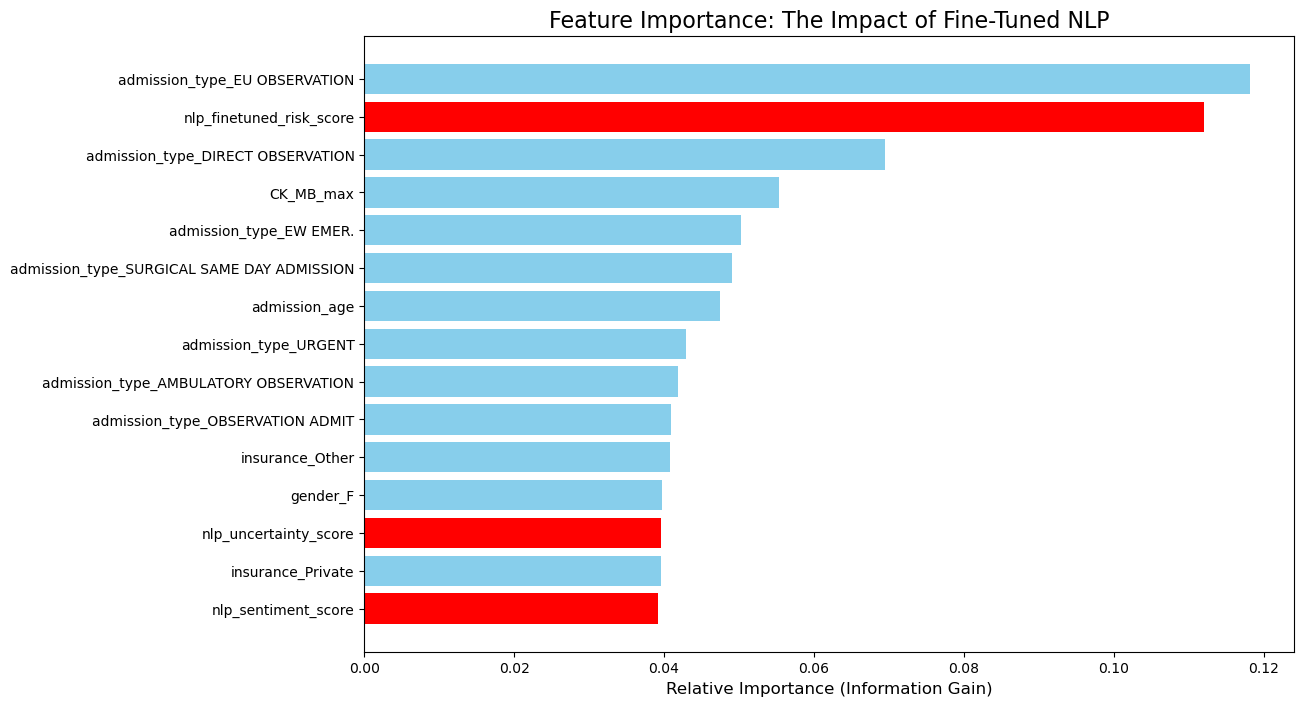

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get feature importance from the trained XGBoost model
importance = model.feature_importances_

# 2. Get the feature names
# We use the 'feature_names_final' array we created when merging the data
# If you lost that variable, we can recreate it easily:
# feature_names_final = np.append(feature_names_original, 'nlp_finetuned_risk_score') 

# 3. Create a DataFrame for plotting
feat_imp = pd.DataFrame({'feature': feature_names_final, 'importance': importance})

# 4. Sort and take the Top 15
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

# 5. Plot
plt.figure(figsize=(12, 8))
# We use a specific color for the NLP feature to make it stand out
colors = ['red' if 'nlp' in x else 'skyblue' for x in feat_imp['feature']]

plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors)
plt.gca().invert_yaxis() # Highest importance at the top
plt.title("Feature Importance: The Impact of Fine-Tuned NLP", fontsize=16)
plt.xlabel("Relative Importance (Information Gain)", fontsize=12)
plt.show()

Calculating SHAP for 50 patients...


100%|██████████| 50/50 [00:00<00:00, 64.64it/s]


✅ Detected Array output (50, 22, 2). Slicing [:, :, 1]...
Final SHAP Shape: (50, 22)
Final Data Shape: (50, 22)


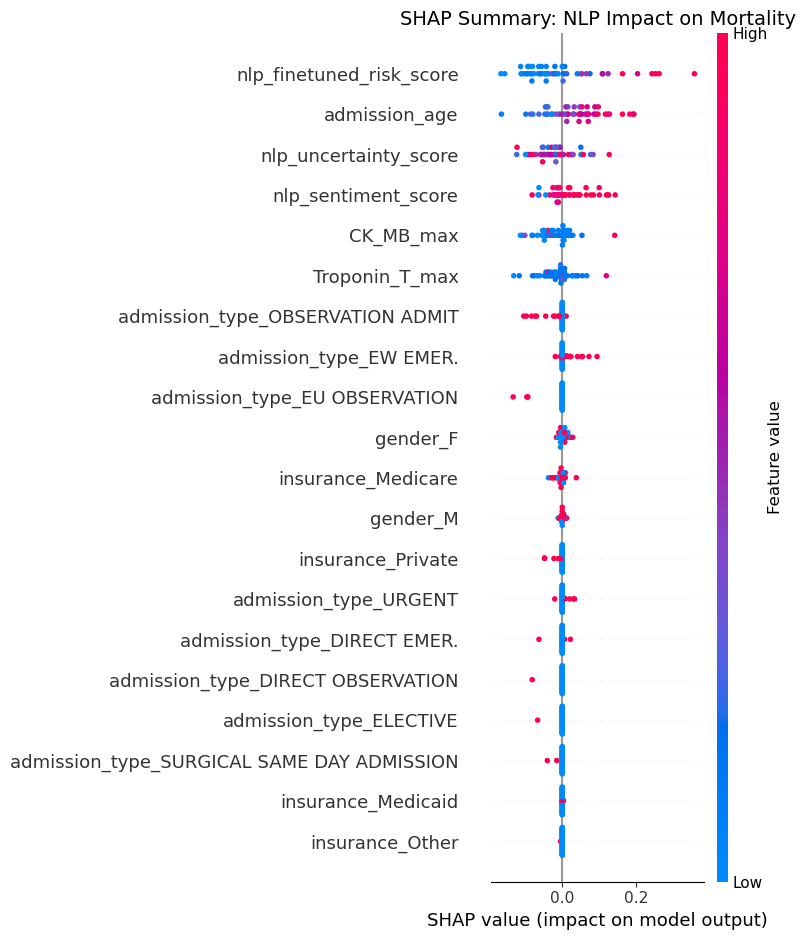


Generating Waterfall for Patient #41 (Risk: 0.7360)


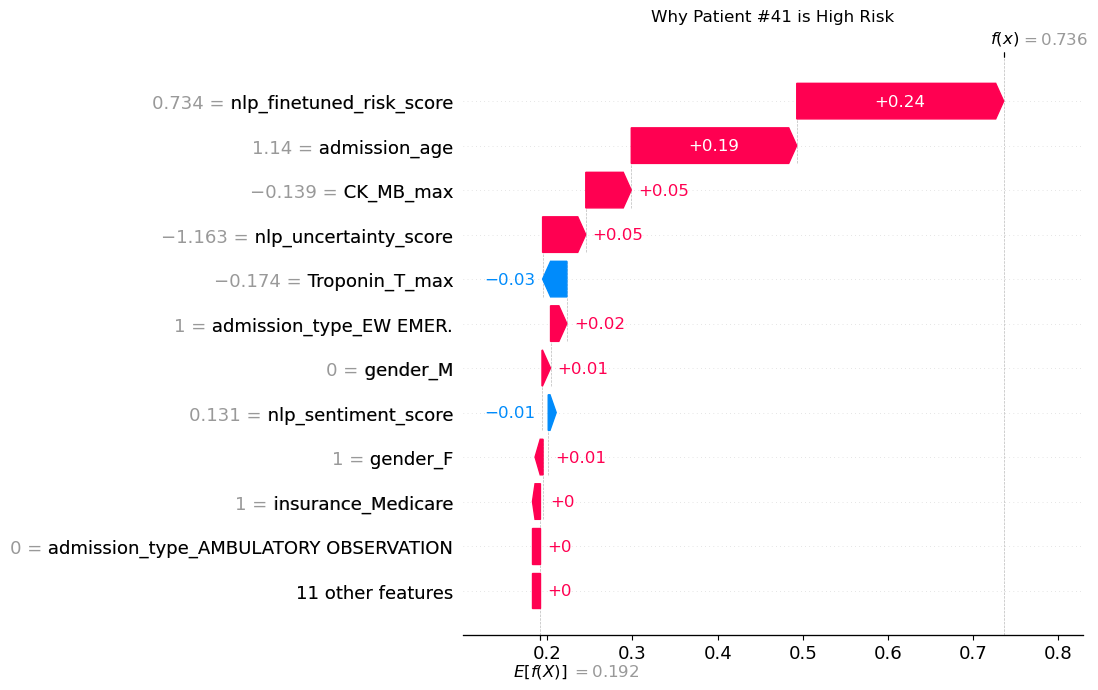

In [20]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SETUP ---
# Background data for baseline
X_summary = shap.kmeans(X_train, 10) 
explainer = shap.KernelExplainer(model.predict_proba, X_summary)

# --- 2. CALCULATE SHAP ---
num_patients = 50
print(f"Calculating SHAP for {num_patients} patients...")
shap_values_all = explainer.shap_values(X_test[:num_patients], nsamples=100)

# --- 3. ROBUST EXTRACTION (The Fix) ---
# Check if it's a list (old behavior) or an array (new behavior)
if isinstance(shap_values_all, list):
    print("✅ Detected List output. Extracting Index 1...")
    shap_values_death = shap_values_all[1]
else:
    print(f"✅ Detected Array output {shap_values_all.shape}. Slicing [:, :, 1]...")
    # If it's (Samples, Features, Classes), we want all samples, all features, Class 1
    shap_values_death = shap_values_all[:, :, 1]

# Double check shapes
print(f"Final SHAP Shape: {shap_values_death.shape}")
print(f"Final Data Shape: {X_test[:num_patients].shape}")

# --- 4. PLOT 1: BEESWARM ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_death, X_test[:num_patients], feature_names=feature_names_final, show=False)
plt.title("SHAP Summary: NLP Impact on Mortality", fontsize=14)
plt.tight_layout()
plt.show()

# --- 5. PLOT 2: WATERFALL ---
# Find highest risk patient
probs = model.predict_proba(X_test[:num_patients])[:, 1]
high_risk_idx = np.argmax(probs)

print(f"\nGenerating Waterfall for Patient #{high_risk_idx} (Risk: {probs[high_risk_idx]:.4f})")

# Handle Expected Value (Base Value) format
base_val = explainer.expected_value
if isinstance(base_val, np.ndarray) or isinstance(base_val, list):
    base_val = base_val[1] # Class 1 base value

exp = shap.Explanation(
    values=shap_values_death[high_risk_idx], 
    base_values=base_val, 
    data=X_test[high_risk_idx], 
    feature_names=feature_names_final
)

plt.figure(figsize=(8, 6))
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title(f"Why Patient #{high_risk_idx} is High Risk")
plt.show()